<a href="https://colab.research.google.com/github/ayoakin/MIVLDE/blob/LLMProbing/subteams/LLMProbing/notebooks/2D_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook to run the experiments related to 2D Linear and eigenvalues

If prompted to restart, press restart.

In [1]:
!pip install numpy==1.25.2

In [2]:
%pip install torch==2.0.0
!pip install odeformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
# give colab permission to access drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Update these as required
repo_path = "/content/drive/MyDrive/Personlig/AISC Mech Interp Diff eq/MIVLDE/subteams/LLMProbing"
odeformer_path = '/content/drive/MyDrive'
samples_path = '/content/drive/MyDrive/aisc/samples'
activations_path = '/content/drive/MyDrive/aisc/activations'
probes_path = '/content/drive/MyDrive/aisc/probes'

In [5]:
import sys
import importlib
sys.path.append(repo_path)
sys.path.append(odeformer_path)

In [6]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import linalg
from tqdm import tqdm

from tqdm.contrib import itertools

In [7]:
from odeformer.metrics import r2_score
from odeformer.model import SymbolicTransformerRegressor
dstr = SymbolicTransformerRegressor(from_pretrained=True)

Downloading...
From (original): https://drive.google.com/uc?id=1L_UZ0qgrBVkRuhg5j3BQoGxlvMk_Pm1W
From (redirected): https://drive.google.com/uc?id=1L_UZ0qgrBVkRuhg5j3BQoGxlvMk_Pm1W&confirm=t&uuid=8be969d9-915f-4705-acf4-958c75a35c85
To: /content/odeformer.pt
100%|██████████| 465M/465M [00:04<00:00, 100MB/s]


Loaded pretrained model


In [8]:
model_args = {'beam_size': 10, 'beam_temperature': 0.5}
dstr.set_model_args(model_args)

In [9]:
%load_ext autoreload
%autoreload 2

x_0' = 1.0383 * x_1
x_1' = -0.9636 * x_0
x_0' = 1.0086 * x_1
x_1' = -0.9876 * x_0


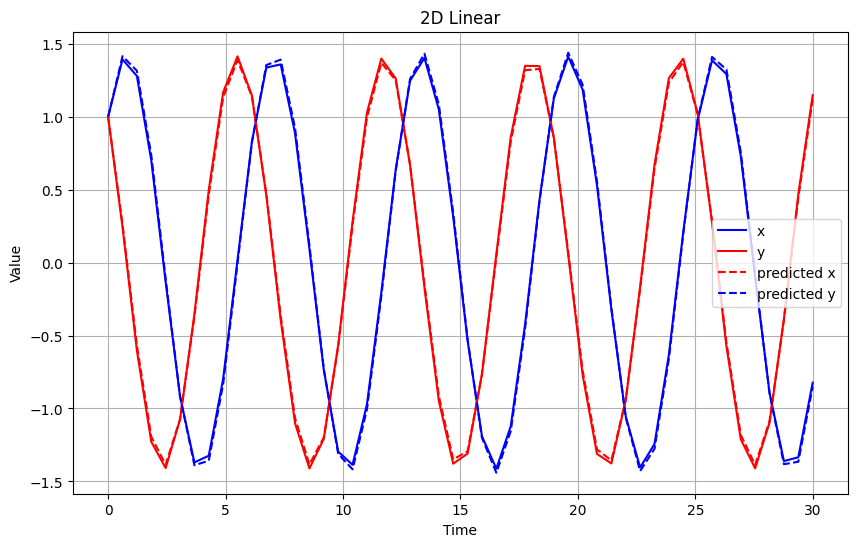

R2 Score:  0.9994260486213665


In [10]:
alpha = 0
beta = 1
gamma = -1
delta = 0


# Defining the system of ODEs
def twodLinear(t, z):
    x, y = z
    dxdt = alpha * x + beta * y
    dydt = gamma * x + delta * y
    return [dxdt, dydt]

# initial conditions
initial_conditions = [1, 1]

# time span and points for the simulation
t_span = (0, 200)
t_points = np.linspace(0, 200, 1000)
t_points = np.linspace(0, 30, 50)

solution = solve_ivp(twodLinear, t_span, initial_conditions, t_eval=t_points)

# extracting prey and predator populations over time
x_values = solution.y[0]
y_values = solution.y[1]
trajectory = np.stack([x_values, y_values], axis=1)
candidates = dstr.fit(t_points, trajectory)
dstr.print(n_predictions=2)
pred_trajectory = dstr.predict(t_points, trajectory[0])

# plotting results
plt.figure(figsize=(10, 6))
plt.plot(t_points, x_values, label='x', color='blue')
plt.plot(t_points, y_values, label='y', color='red')
plt.title("2D Linear")
plt.xlabel("Time")
plt.ylabel("Value")
plt.plot(t_points, pred_trajectory[:, 1], label='predicted x', linestyle='--', color='red')
plt.plot(t_points, pred_trajectory[:, 0], label='predicted y', linestyle='--', color='blue')
plt.legend()
plt.grid(True)
plt.show()
print("R2 Score: " ,r2_score(trajectory, pred_trajectory))

## Manual Sample Generation

In [11]:
# Times array
t_values = np.linspace(1, 10, 50)

# Exponential parameters
alpha_values = np.linspace(-1,1, 5)
beta_values = np.linspace(-1,1, 5)
gamma_values = np.linspace(-1,1, 5)
delta_values = np.linspace(-1,1, 5)
# Hyperbolic parameters
initial_conditions = [1,1]

In [12]:
 def clean_expression(expression):
    # In order to make expressions for equations easier to read
    cleaned = expression.replace('--', '')
    cleaned = cleaned.replace(' -', '-')
    cleaned = cleaned.replace('- ', '-')
    cleaned = cleaned.replace('+-', '-')
    cleaned = cleaned.replace('-+', '-')
    return cleaned

In [13]:
def heaviside(x):
    return 1 if x > 0 else 0

In [14]:
def save_generated_samples(samples, template='sample_man_'):
    for idx, sample in tqdm(enumerate(samples), desc='Saving generated samples'):
        sample_filename = template + f"_{idx}.pt"
        sample_filepath = os.path.join(manual_samples_path, sample_filename)
        os.makedirs(os.path.dirname(sample_filepath), exist_ok=True)
        # Save file using pickle
        with open(sample_filepath, 'wb') as f:
          pickle.dump(sample, f)

In [15]:
dataset_name = '2D'
manual_samples_path = samples_path + '/' + dataset_name
print(manual_samples_path)

/content/drive/MyDrive/aisc/samples/2D


In [16]:
 def generate_2d_samples(t_values, alpha_values, beta_values, gamma_values, delta_values, is_performance_filter = False, performance_filter = -1):
    manual_samples = []
    t_span = (0, 200)
    for alpha in alpha_values:
        for beta in beta_values:
            for gamma in gamma_values:
                for delta in delta_values:
                    def lotka_volterra(t, z):
                      x, y = z
                      dxdt = alpha * x + beta * y
                      dydt = gamma * x + delta * y
                      return [dxdt, dydt]

                    solution = solve_ivp(lotka_volterra, t_span, initial_conditions, t_eval=t_values)
                    x = solution.y[0]
                    y = solution.y[1]
                    trajectory = np.stack([x, y], axis=1)

                    A = np.array([[alpha, beta],
                      [gamma, delta]])

                    # Calculate eigenvalues
                    eigenvalues = linalg.eigvals(A)
                    real_parts = np.real(eigenvalues)
                    imag_parts = np.imag(eigenvalues)
                    sample_dict = {
                        'times' : t_values,
                        'trajectory': trajectory,
                        'parameters': {'alpha': float(alpha), 'beta': float(beta), 'gamma': float(gamma), 'delta': float(delta)}, # Convert to float for better serialization
                        'feature_dict': {"real_0": real_parts[0],"real_1": real_parts[1], "imag_0": imag_parts[0], "imag_1" : imag_parts[1], "real_0_positive" : heaviside(real_parts[0]),
                                         "real_1_positive" : heaviside(real_parts[1]), "imag_0_positive" : heaviside(imag_parts[0]), "imag_1_positive" : heaviside(imag_parts[1]),
                                         "alpha" : float(alpha), 'beta': float(beta), 'gamma': float(gamma), 'delta': float(delta),
                                         "alpha_positive" : heaviside(float(alpha)), "beta_positive" : heaviside(float(beta)), "gamma_positive" : heaviside(float(gamma)), "delta_positive" : heaviside(float(delta))},
                        'expression': clean_expression(f"dxdt = {alpha} * x + {beta} * y, dydt = {gamma} * x + {delta} * y")
                    }
                    print('expression: ', clean_expression(f"dxdt = {alpha} * x + {beta} * y, dydt = {gamma} * x + {delta} * y"))
                    print('real_part: ', real_parts)
                    print('imag_part: ', imag_parts)

                    manual_samples.append(sample_dict)

    if not os.path.exists(manual_samples_path):
      os.makedirs(manual_samples_path)
    save_generated_samples(manual_samples, template='sample_' + dataset_name)
    return 0


In [ ]:
generate_2d_samples(t_values, alpha_values, beta_values, gamma_values, delta_values)

expression:  dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x -1.0 * y
real_part:  [ 0. -2.]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x -0.5 * y
real_part:  [-1.78077641  0.28077641]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x + 0.0 * y
real_part:  [-1.61803399  0.61803399]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x + 0.5 * y
real_part:  [-1.5  1. ]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x + 1.0 * y
real_part:  [-1.41421356  1.41421356]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-0.5 * x -1.0 * y
real_part:  [-0.29289322 -1.70710678]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-0.5 * x -0.5 * y
real_part:  [-1.5  0. ]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-0.5 * x + 0.0 * y
real_part:  [-1.3660254  0.3660254]
imag_part:  [0. 0.]
expression:  dxdt =-1.0 * x -1.0 * y, dydt =-0.5 * x + 0.5 * y
real_part:  [-1.280

Saving generated samples: 625it [02:28,  4.22it/s]


0

## Corresponding Activations Extraction

In [17]:
from src.activation_extraction import ActivationsExtractor

In [18]:
manual_activations_path = f'{activations_path}/{dataset_name}'
act_extractor = ActivationsExtractor()

In [ ]:
print(manual_activations_path)
print(manual_samples_path)

/content/drive/MyDrive/aisc/activations/2D
/content/drive/MyDrive/aisc/samples/2D


In [ ]:
act_extractor.extract_activations(dstr, manual_samples_path, manual_activations_path, layers_to_extract=['ffn'])

Extracting Activations:  15%|█▌        | 94/625 [09:16<1:00:49,  6.87s/it]


nan in trajectory of sample 2D_93


Extracting Activations:  42%|████▏     | 264/625 [27:00<44:33,  7.41s/it]


nan in trajectory of sample 2D_263


Extracting Activations:  45%|████▌     | 284/625 [28:46<38:18,  6.74s/it]

...


nan in trajectory of sample 2D_564


Extracting Activations:  93%|█████████▎| 582/625 [1:08:36<06:54,  9.63s/it]


nan in trajectory of sample 2D_581


Extracting Activations: 100%|██████████| 625/625 [1:14:57<00:00,  7.20s/it]


[INFO] Activation extraction complete. Activations saved to /content/drive/MyDrive/aisc/activations/2D


In [ ]:
# Inspect a manual activation and display its keys and some values
manual_acts_dir = os.fsencode(manual_activations_path)
for acts_file in os.listdir(manual_acts_dir):
  acts_name = os.fsdecode(acts_file)
  manual_acts_path = os.path.join(manual_activations_path, acts_name)
  with open(manual_acts_path, 'rb') as f:
      manual_acts = pickle.load(f)


  print(manual_acts['expression'])
  print(manual_acts['feature_dict']['r2_score'])
  print(manual_acts['feature_dict'])
  break

dxdt =-1.0 * x -1.0 * y, dydt =-1.0 * x -1.0 * y
0.9998550778862512
{'real_0': 0.0, 'real_1': -2.0, 'imag_0': 0.0, 'imag_1': 0.0, 'real_0_positive': 0, 'real_1_positive': 0, 'imag_0_positive': 0, 'imag_1_positive': 0, 'alpha': -1.0, 'beta': -1.0, 'gamma': -1.0, 'delta': -1.0, 'alpha_positive': 0, 'beta_positive': 0, 'gamma_positive': 0, 'delta_positive': 0, 'r2_score': 0.9998550778862512}


## Probe Training

In [ ]:
import experiments

In [19]:
print(probes_path)
dataset_name = '2D'
print(manual_activations_path)

/content/drive/MyDrive/aisc/probes
/content/drive/MyDrive/aisc/activations/2D


In [ ]:
target_feature = 'real_0'
r2_threshold = -1
#r2_threshold = 0.9
if r2_threshold == -1:
  r2_string = ''
else:
  r2_string = '_' + str(r2_threshold)

probes_path_full = f'{probes_path}/{dataset_name}'+str(r2_string) +f'/{target_feature}'
print(probes_path_full)

/content/drive/MyDrive/aisc/probes/2D/real_0


In [ ]:
layers = [idx for idx in range(0, 16)]
#probes_path_3 = probes_path + '/derivative_3'



expt_results = experiments.run_experiment.scalar_prediction_experiment_w_solver(target_feature=target_feature, activations_path=manual_activations_path, \
                     probes_path=probes_path_full, \
                     layers=layers, r2_threshold=r2_threshold)
# save experiment results
with open(f'{probes_path_full}/experiment_data.pt', 'wb') as f:
    pickle.dump(expt_results, f)


Training on each layer:   6%|▋         | 1/16 [00:21<05:18, 21.22s/it]

Regression probe trained on layer 0: Test Set Loss 1.1147881637187917
Saved state dictionary to /content/drive/MyDrive/aisc/probes/2D/real_0/probe_real_0_0_0.pt



Training on each layer:  12%|█▎        | 2/16 [00:38<04:24, 18.91s/it]

Regression probe trained on layer 1: Test Set Loss 0.8669658334775401
Saved state dictionary to /content/drive/MyDrive/aisc/probes/2D/real_0/probe_real_0_1_0.pt



Training on each layer:  19%|█▉        | 3/16 [00:56<04:02, 18.67s/it]

...

Regression probe trained on layer 13: Test Set Loss 13.939500653512914
Saved state dictionary to /content/drive/MyDrive/aisc/probes/2D/real_0/probe_real_0_13_0.pt



Training on each layer:  94%|█████████▍| 15/16 [04:36<00:18, 18.88s/it]

Regression probe trained on layer 14: Test Set Loss 5.3259582341784455
Saved state dictionary to /content/drive/MyDrive/aisc/probes/2D/real_0/probe_real_0_14_0.pt



Training on each layer: 100%|██████████| 16/16 [04:53<00:00, 18.33s/it]

Regression probe trained on layer 15: Test Set Loss 2.5062727526237722
Saved state dictionary to /content/drive/MyDrive/aisc/probes/2D/real_0/probe_real_0_15_0.pt


In [ ]:
expt_results_real_0 = expt_results
spearman_real_0 = expt_results_real_0['test_spearman']

In [ ]:
expt_results_real_0

,layer,test_loss,final_train_loss,final_val_loss,test_r2,test_spearman,test_pearson
0,0,1.114788,3.742645e-10,1.177609,-0.993001,0.333877,0.369766
1,1,0.866966,1.056453e-10,0.990625,-0.549948,0.295524,0.289399
2,2,0.848231,3.708537e-09,0.701680,-0.516455,0.298070,0.291152
3,3,0.750224,2.287981e-06,0.699261,-0.341238,0.347613,0.345734
4,4,0.658023,3.280642e-01,1.604704,-0.176404,0.364403,0.375801
5,5,1.088760,4.809953e-01,8.852666,-0.946468,0.388652,0.132935
6,6,0.912022,5.410653e-01,23.830176,-0.630498,0.086833,0.071016
7,7,0.627563,4.652634e-01,0.820146,-0.121947,0.358355,0.303323
8,8,0.638715,2.801457e-01,0.579860,-0.141885,0.230035,0.283470
9,9,1.517768,1.229839e-01,2.343720,-1.713443,0.206341,0.202316


In [ ]:
expt_results_alpha

,layer,test_loss,final_train_loss,final_val_loss,test_r2,test_spearman,test_pearson
0,0,0.536498,2.947699e-10,0.721043,-0.184176,0.532776,0.531062
1,1,0.400556,7.908490e-11,0.519307,0.115879,0.537294,0.550310
2,2,0.419563,2.005108e-09,0.512658,0.073925,0.465911,0.497290
3,3,0.331485,1.119392e-06,0.428269,0.268335,0.601528,0.616592
4,4,0.652535,2.624464e-01,0.736946,-0.440299,0.328634,0.370746
5,5,0.718156,3.110256e-01,24.802714,-0.585138,0.356947,0.212450
6,6,1.110730,5.473364e-01,13.109864,-1.451643,0.261819,0.132636
7,7,0.402275,3.596110e-01,0.687863,0.112084,0.527227,0.465804
8,8,0.432449,1.674182e-01,0.421707,0.045483,0.424814,0.438336
9,9,1.358248,8.076001e-02,1.623878,-1.997972,0.382916,0.255604


In [ ]:
target_feature = 'alpha'
r2_threshold = -1
#r2_threshold = 0.9
if r2_threshold == -1:
  r2_string = ''
else:
  r2_string = '_' + str(r2_threshold)

probes_path_full = f'{probes_path}/{dataset_name}'+str(r2_string) +f'/{target_feature}'

In [ ]:
with open(f'{probes_path_full}/experiment_data.pt', 'rb') as f:
    expt_results_alpha = pickle.load(f)
spearman_alpha = expt_results_alpha['test_spearman']

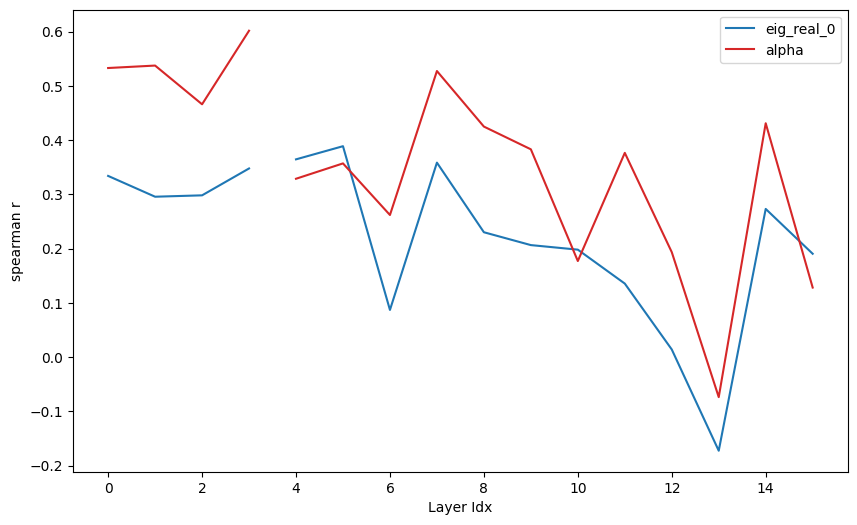

In [ ]:
group1_colors = ['tab:blue', 'tab:cyan', 'royalblue', 'navy']

# Second group - reds/warm colors
group2_colors = ['tab:red', 'tab:orange', 'firebrick', 'darkred']

plt.figure(figsize=(10, 6))
plt.plot(layers[:4], spearman_real_0[:4], label='eig_real_0', color = group1_colors[0])
plt.plot(layers[4:], spearman_real_0[4:], color = group1_colors[0])
#plt.plot(layers[:4], spearman_real_1_2[:4], label='eig_real_1', color = group1_colors[1])
#plt.plot(layers[4:], spearman_real_1_2[4:], color = group1_colors[1])
#plt.plot(layers[:4], spearman_imag_0_2[:4], label='eig_imag', color = group1_colors[2])
#plt.plot(layers[4:], spearman_imag_0_2[4:], color = group1_colors[2])
plt.plot(layers[:4], spearman_alpha[:4], label='alpha', color = group2_colors[0])
plt.plot(layers[4:], spearman_alpha[4:], color = group2_colors[0])
#plt.plot(layers[:4], spearman_beta[:4], label='beta', color = group2_colors[1])
#plt.plot(layers[4:], spearman_beta[4:], color = group2_colors[1])
#plt.plot(layers[:4], spearman_gamma_2[:4], label='gamma', color = group2_colors[2])
#plt.plot(layers[4:], spearman_gamma_2[4:], color = group2_colors[2])
#plt.plot(layers[:4], spearman_delta_2[:4], label='delta', color = group2_colors[3])
#plt.plot(layers[4:], spearman_delta_2[4:], color = group2_colors[3])
#plt.plot(x, y3, label='sin(x)*cos(x)', color='green')
plt.xlabel("Layer Idx")
plt.ylabel("spearman r")
plt.legend()

In [ ]:
spearman_eig_average = np.mean([spearman_real_0,spearman_real_1, spearman_imag_0], axis = 0)
spearman_coef_average = np.mean([spearman_alpha,spearman_beta, spearman_gamma, spearman_delta], axis = 0)

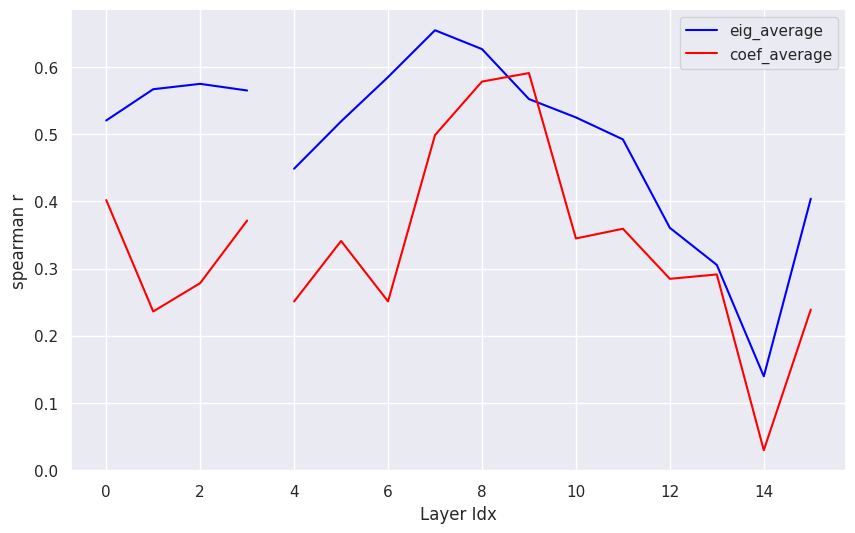

In [ ]:
group1_colors = ['tab:blue', 'tab:cyan', 'royalblue', 'navy']

# Second group - reds/warm colors
group2_colors = ['tab:red', 'tab:orange', 'firebrick', 'darkred']

plt.figure(figsize=(10, 6))
plt.plot(layers[:4], spearman_eig_average[:4], label='eig_average', color = 'blue')
plt.plot(layers[4:], spearman_eig_average[4:], color = 'blue')

plt.plot(layers[:4], spearman_coef_average[:4], label='coef_average', color = 'red')
plt.plot(layers[4:], spearman_coef_average[4:], color = 'red')
#plt.plot(x, y3, label='sin(x)*cos(x)', color='green')
plt.xlabel("Layer Idx")
plt.ylabel("spearman r")
plt.legend()